# 🏦 EXP-09 — Domain-Specific Embeddings Benchmark

**Goal:** Test 4 embedding models on an identical 15-document financial corpus + 30 questions.  
**Metric:** Retrieval Precision@5  
**Question:** When does domain-specific embedding actually matter vs a general model?

| ID | Model | Type |
|----|-------|------|
| A  | `all-MiniLM-L6-v2` | General baseline (384-dim) |
| B  | `BAAI/bge-m3` | General multilingual (1024-dim) |
| C  | `yiyanghkust/finbert-tone` | FinBERT — financial news & filings |
| D  | `nickmuchi/finance-embeddings-investopedia` | Finance-specific — Investopedia |

---
### ⚡ Runtime Tips
- Go to **Runtime → Change runtime type → T4 GPU** before running (free tier)
- Cell 1 installs deps (~1 min). Models download on first use and are **cached in Colab's session** — no re-download if you re-run later cells.
- Total runtime: ~5 min on GPU, ~15 min on CPU
- At the end, **download all output files** from the Files panel (left sidebar → 📁 icon → `exp09_outputs/`)

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# Run once per session. Takes ~60 seconds.
# ─────────────────────────────────────────────────────────────────
!pip install -q chromadb sentence-transformers numpy
print('\n✅ All dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Verify GPU is available (optional but recommended)
# ─────────────────────────────────────────────────────────────────
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'✅ GPU detected: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU found — running on CPU (slower but works fine).')
    print('   Tip: Runtime → Change runtime type → T4 GPU')

✅ GPU detected: Tesla T4
   VRAM: 15.6 GB


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Imports & Configuration
# ─────────────────────────────────────────────────────────────────
import os, json, time, textwrap
from pathlib import Path
from datetime import datetime

import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer
import numpy as np

# ── Model registry ────────────────────────────────────────────────
MODELS = {
    'A_MiniLM': {
        'hf_name'   : 'sentence-transformers/all-MiniLM-L6-v2',
        'label'     : 'all-MiniLM-L6-v2 (General baseline)',
        'collection': 'exp09_minilm',
    },
    'B_BGE_M3': {
        'hf_name'   : 'BAAI/bge-m3',
        'label'     : 'BAAI/bge-m3 (General multilingual)',
        'collection': 'exp09_bge_m3',
    },
    'C_FinBERT': {
        'hf_name'   : 'yiyanghkust/finbert-tone',
        'label'     : 'yiyanghkust/finbert-tone (FinBERT)',
        'collection': 'exp09_finbert',
    },
    'D_Finance_Investopedia': {
        'hf_name'   : 'nickmuchi/finance-embeddings-investopedia',
        'label'     : 'nickmuchi/finance-embeddings-investopedia (Finance-specific)',
        'collection': 'exp09_finance_invest',
    },
}

TOP_K       = 5
CHROMA_PATH = '/content/chroma_exp09'
OUTPUT_DIR  = Path('/content/exp09_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Configuration loaded.')
print(f'   Output directory: {OUTPUT_DIR}')
print(f'   ChromaDB path:    {CHROMA_PATH}')
print(f'   Device:           {device}')

✅ Configuration loaded.
   Output directory: /content/exp09_outputs
   ChromaDB path:    /content/chroma_exp09
   Device:           cuda


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Financial Corpus (15 documents)
# ─────────────────────────────────────────────────────────────────
CORPUS = [
    {
        'id': 'DOC-1', 'title': 'Introduction to Commercial Banking',
        'text': (
            'Commercial banking forms the backbone of modern financial systems. Banks accept deposits from the '
            'public and extend credit to businesses and individuals, creating a vital intermediary role in the '
            'economy. The primary functions of a commercial bank include accepting demand and time deposits, '
            'granting loans and advances, discounting bills of exchange, safe custody of valuables, and providing '
            'remittance services.\n\n'
            'Net Interest Margin (NIM) is one of the most critical profitability metrics for commercial banks. '
            'NIM is calculated as the difference between interest income earned on loans and investments and '
            'interest paid on deposits and borrowings, divided by average earning assets. A healthy NIM typically '
            'ranges from 2.5% to 4.5% for retail banks in developed economies.\n\n'
            'The Capital Adequacy Ratio (CAR), also known as CRAR, measures a bank\'s capital in relation to its '
            'risk-weighted assets. Under Basel III standards, banks must maintain a minimum Tier 1 capital ratio '
            'of 6% and a total capital ratio of 8%. The conservation buffer of 2.5% brings the effective minimum '
            'total capital requirement to 10.5%.\n\n'
            'Loan-to-Deposit Ratio (LDR) measures total loans extended relative to total deposits. Regulators '
            'typically prefer LDRs between 80% and 90%.'
        ),
    },
    {
        'id': 'DOC-2', 'title': 'Credit Risk Management',
        'text': (
            'Credit risk is the possibility of a loss resulting from a borrower\'s failure to repay a loan or '
            'meet contractual obligations. It is the most significant risk faced by commercial banks. Credit '
            'risk manifests in default risk, migration risk, concentration risk, and settlement risk.\n\n'
            'Non-Performing Loans (NPLs) are loans where the borrower has not made scheduled payments for 90 '
            'days or more. NPL ratio = NPLs / total gross loans. Banks with NPL ratios above 5% are '
            'considered to have significant credit quality problems.\n\n'
            'The Expected Loss (EL) model: EL = PD x LGD x EAD, where PD is Probability of Default, LGD is '
            'Loss Given Default, and EAD is Exposure at Default. PD estimates default likelihood; LGD represents '
            'the portion lost after collateral recovery; EAD is the outstanding amount at default.\n\n'
            'Credit scoring models (e.g., FICO 300-850) assign numerical scores based on payment history, '
            'outstanding debt, credit history length, new inquiries, and credit mix. Scores above 740 are '
            'excellent; below 580 indicate poor creditworthiness.\n\n'
            'Collateral management: Loan-to-Value (LTV) ratio = loan amount / appraised collateral value. '
            'Lenders typically require LTV below 80% for residential mortgages.'
        ),
    },
    {
        'id': 'DOC-3', 'title': 'Liquidity Risk and Asset-Liability Management',
        'text': (
            'Liquidity risk refers to the inability of a bank to meet its financial obligations without '
            'incurring unacceptable losses. Two dimensions: funding liquidity risk and market liquidity risk.\n\n'
            'The Liquidity Coverage Ratio (LCR) under Basel III requires banks to hold sufficient High-Quality '
            'Liquid Assets (HQLA) to cover 100% of net cash outflows over a 30-day stress period. HQLA includes '
            'Level 1 assets (cash, central bank reserves, sovereign bonds — no haircut), Level 2A assets '
            '(15% haircut), and Level 2B assets (25-50% haircuts).\n\n'
            'The Net Stable Funding Ratio (NSFR) addresses structural liquidity over one year. Available Stable '
            'Funding (ASF) must equal or exceed Required Stable Funding (RSF). Retail deposits have high ASF '
            'factors (90-95%) due to their stability; short-term wholesale funding has low ASF factors (0-50%).\n\n'
            'Asset-Liability Management (ALM) manages mismatches between assets and liabilities. Duration gap '
            'analysis measures sensitivity of net interest income to interest rate changes.\n\n'
            'Funds Transfer Pricing (FTP) allocates the cost and benefit of funds across business lines.'
        ),
    },
    {
        'id': 'DOC-4', 'title': 'Investment Banking and Capital Markets',
        'text': (
            'Investment banking encompasses underwriting, M&A advisory, securities trading, and asset management, '
            'primarily serving corporations, governments, and institutional investors.\n\n'
            'Underwriting: In firm commitment underwriting, the bank purchases the entire securities issue and '
            'bears the sale risk. In best efforts underwriting, the bank sells as much as possible without '
            'guaranteeing the full amount. IPOs represent the first public sale of a company\'s shares.\n\n'
            'M&A advisory valuation: Discounted Cash Flow (DCF) analysis, Comparable Company Analysis (CCA), '
            'Precedent Transaction Analysis, and Leveraged Buyout (LBO) modeling. DCF values a company based '
            'on present value of projected future cash flows discounted at WACC.\n\n'
            'Structured Finance: CDOs pool debt (mortgages, loans, bonds) and issue tranches. The senior '
            'tranche receives payment first (lowest risk); the equity tranche absorbs losses first '
            '(highest risk/return). ABS and MBS are common structured products.'
        ),
    },
    {
        'id': 'DOC-5', 'title': 'Derivatives and Risk Management',
        'text': (
            'Derivatives are financial contracts whose value derives from an underlying asset. Categories: '
            'forwards, futures, options, and swaps. Used for hedging and speculation.\n\n'
            'Interest Rate Swaps (IRS): parties exchange fixed for floating rate payments (LIBOR/SOFR). A '
            'company with floating-rate debt enters a pay-fixed, receive-floating swap to convert to fixed '
            'rate, eliminating interest rate uncertainty.\n\n'
            'Options grant the right (not obligation) to buy (call) or sell (put) at a strike price. '
            'Black-Scholes-Merton model incorporates asset price, strike price, risk-free rate, time to '
            'expiration, and implied volatility. The Greeks: Delta, Gamma, Theta, Vega, Rho.\n\n'
            'Credit Default Swaps (CDS): buyer pays periodic premiums; seller compensates on a credit event '
            '(default, restructuring, bankruptcy). CDS spreads are market-implied default probability measures.\n\n'
            'Value at Risk (VaR): maximum potential loss over a given horizon at a confidence level. '
            'Methodologies: Historical Simulation, Parametric (Variance-Covariance), Monte Carlo Simulation.'
        ),
    },
    {
        'id': 'DOC-6', 'title': 'Regulatory Framework and Compliance',
        'text': (
            'The Basel Accords: Basel I (1988) introduced risk-weighted capital requirements. Basel II (2004) '
            'three pillars: minimum capital, supervisory review, market discipline. Basel III (2010-2019) '
            'strengthened capital and liquidity standards post-2008 crisis.\n\n'
            'Dodd-Frank (2010): Volcker Rule prohibits proprietary trading by banks. Created CFPB, enhanced '
            'oversight of SIFIs, mandated central clearing for OTC derivatives.\n\n'
            'KYC/AML: Banks verify customer identities and monitor for suspicious activity. Bank Secrecy Act '
            'requires Currency Transaction Reports (CTRs) for cash >$10,000 and Suspicious Activity Reports '
            '(SARs) for potentially illicit activities.\n\n'
            'Stress testing: CCAR (Federal Reserve) requires large banks to demonstrate capital adequacy '
            'under severely adverse scenarios. DFAST extends this to medium-sized banks.\n\n'
            'IFRS 9 ECL model: Stage 1 = 12-month ECL (no significant deterioration). '
            'Stage 2 = lifetime ECL (significant credit deterioration). Stage 3 = lifetime ECL (credit-impaired).'
        ),
    },
    {
        'id': 'DOC-7', 'title': 'Retail Banking Products',
        'text': (
            'Retail banking offers checking/savings accounts, CDs, mortgages, personal loans, auto loans, '
            'credit cards, and insurance products to individual consumers and small businesses.\n\n'
            'Mortgages: Fixed-rate (constant interest), ARMs (tied to SOFR/Treasury index), interest-only, '
            'and government-backed (FHA, VA, USDA). Amortization schedules split payments between principal '
            'and interest.\n\n'
            'Credit cards: Interchange fees 1.5-3.5%. APR typically 15-30%. Credit utilization ratio = '
            'outstanding balance / credit limit; ratios below 30% recommended.\n\n'
            'Deposit insurance: FDIC insures U.S. deposits up to $250,000 per depositor per bank per account '
            'category. EU Deposit Guarantee Schemes provide EUR 100,000 coverage. Deposit insurance creates '
            'moral hazard.\n\n'
            'Open Banking mandated by PSD2 in Europe requires banks to share customer data with authorized '
            'third parties via APIs. Neobanks (digital-only) attract customers with lower fees. BNPL products '
            'have grown rapidly.'
        ),
    },
    {
        'id': 'DOC-8', 'title': 'Corporate Finance and Valuation',
        'text': (
            'Corporate finance: Capital structure, investment decisions, and shareholder value. '
            'Modigliani-Miller theorem: in frictionless markets, capital structure is irrelevant.\n\n'
            'WACC = (E/V) x Ke + (D/V) x Kd x (1-T), where E=equity, D=debt, V=total value, '
            'Ke=cost of equity, Kd=cost of debt, T=tax rate. CAPM: Ke = Rf + beta x (Rm - Rf).\n\n'
            'FCFF = EBIT x (1-T) + Depreciation - CapEx - delta NWC. Enterprise Value = NPV of FCFF at WACC. '
            'Equity Value = Enterprise Value minus Net Debt.\n\n'
            'EV/EBITDA multiples: technology 20-40x; utilities 8-12x. P/E and P/B used in comparable '
            'company analysis. For banks, P/B and P/TBV are especially important.\n\n'
            'Cash Conversion Cycle (CCC) = Days Sales Outstanding + Days Inventory Outstanding - '
            'Days Payable Outstanding. Shorter CCC = more efficient working capital management.'
        ),
    },
    {
        'id': 'DOC-9', 'title': 'Fixed Income and Bond Markets',
        'text': (
            'Fixed income securities are debt obligations promising coupon payments and principal repayment. '
            'Bond prices and yields are inversely related.\n\n'
            'Government bonds (Treasuries): T-bills, T-notes, T-bonds serve as benchmark risk-free rates. '
            'TIPS adjust principal for inflation. The 10-year Treasury yield is the most widely watched '
            'financial indicator.\n\n'
            'Bond ratings: Investment-grade (BBB-/Baa3 or above) — lower yields, lower default risk. '
            'High-yield/junk (below BBB-/Baa3) — higher yields, higher default risk. Investment-grade '
            'spreads: 50-200 bps. High-yield spreads: 300-600 bps in normal markets.\n\n'
            'Duration: weighted average time to receive cash flows; primary measure of interest rate '
            'sensitivity. Modified duration approximates % price change per 1% yield change. '
            'A bond with modified duration 5 loses ~5% when yields rise 1%. Convexity captures '
            'non-linear price-yield relationship.\n\n'
            'Bond strategies: passive (index replication), active (rate bets), liability-driven investing (LDI).'
        ),
    },
    {
        'id': 'DOC-10', 'title': 'Financial Ratios and Analysis',
        'text': (
            'Financial ratio analysis evaluates performance, liquidity, leverage, and valuation.\n\n'
            'Profitability: ROA = Net Income / Avg Assets (banks: >1% good). ROE = Net Income / Avg Equity '
            '(bank target 10-15%). RORWA = Net Income / Risk-Weighted Assets.\n\n'
            'Leverage: Debt/Equity ratio. Interest Coverage = EBIT / Interest Expense (below 1.5x = distress '
            'risk). Basel III bank leverage ratio = Tier 1 / Total Exposure (min 3%). DuPont: '
            'ROE = Net Profit Margin x Asset Turnover x Equity Multiplier.\n\n'
            'Efficiency: Cost-to-Income Ratio (CIR) = Operating Expenses / Operating Income; below 50% = '
            'high efficiency for banks. Asset Turnover = Revenue / Avg Assets.\n\n'
            'Liquidity: Current Ratio = Current Assets / Current Liabilities (1.5-2.0 healthy). Quick Ratio '
            '= (Current Assets - Inventory) / Current Liabilities. LCR and NSFR for banks.\n\n'
            'Valuation: P/E, P/B, EV/EBITDA, Price/Sales, PEG ratio. For banks: P/B and P/TBV most important.'
        ),
    },
    {
        'id': 'DOC-11', 'title': 'Monetary Policy and Central Banking',
        'text': (
            'Central banks manage monetary policy, issue currency, regulate financial systems, and act as '
            'lender of last resort. Key central banks: Federal Reserve, ECB, BoE, BoJ, PBoC.\n\n'
            'Monetary policy tools: open market operations (OMO), discount rate, reserve requirements, '
            'forward guidance. OMO: buying securities injects liquidity (expansionary); selling drains '
            'liquidity (contractionary). Federal Funds Rate is the primary U.S. policy rate.\n\n'
            'Quantitative Easing (QE): central bank purchases longer-term securities when short-term rates '
            'near zero. Fed balance sheet grew from ~$900B (2008) to >$8T (2022). QE channels: portfolio '
            'balance effects, wealth effects, exchange rate channel.\n\n'
            'Inflation targeting: Fed (2% PCE), ECB (2% HICP), BoE (2% CPI). Taylor Rule: '
            'i = r* + pi + 0.5(pi - pi*) + 0.5(Y - Y*), where r* = neutral real rate, pi = actual inflation, '
            'pi* = target, Y = output, Y* = potential output.\n\n'
            'Yield curve and monetary transmission channels: interest rate, credit, exchange rate, '
            'asset price, and expectations channels.'
        ),
    },
    {
        'id': 'DOC-12', 'title': 'Financial Statement Analysis',
        'text': (
            'Financial statements: income statement (revenues/expenses/profits over a period), balance sheet '
            '(assets/liabilities/equity at a point in time), cash flow statement (operating/investing/financing).\n\n'
            'DuPont Analysis: ROE = Net Profit Margin x Asset Turnover x Financial Leverage = '
            '(Net Income/Revenue) x (Revenue/Assets) x (Assets/Equity). Reveals whether ROE improvement '
            'comes from margin, efficiency, or leverage. Extended DuPont adds tax burden, interest burden.\n\n'
            'Earnings quality: High-quality earnings are cash-based, recurring, economically derived. Red '
            'flags: high accruals ratio, revenue acceleration, expense capitalization, channel stuffing. '
            'Beneish M-Score uses 8 ratios to detect earnings manipulation.\n\n'
            'Cash flow analysis: Free Cash Flow Yield = FCF / Enterprise Value. Cash conversion efficiency '
            '= Operating CF / EBITDA (should approach 100% for high-quality earnings).\n\n'
            'Segment analysis: geographic and business segment margins reveal competitive position. '
            'Customer concentration risk when top customers dominate revenue.'
        ),
    },
    {
        'id': 'DOC-13', 'title': 'Risk Management Frameworks',
        'text': (
            'Enterprise Risk Management (ERM): holistic framework for identifying, measuring, managing, and '
            'monitoring all risks. COSO ERM and ISO 31000 are widely adopted standards.\n\n'
            'Operational risk: loss from failed processes, people, systems, or external events. Basel III '
            'capital approaches: Basic Indicator, Standardized, Advanced Measurement. Key Risk Indicators '
            '(KRIs) provide early warning signals.\n\n'
            'Counterparty Credit Risk (CCR): arises in derivatives when counterparty defaults before '
            'settlement. Credit Valuation Adjustment (CVA) = market value of CCR, adjusting derivative fair '
            'values for expected counterparty losses. Potential Future Exposure (PFE) = max likely exposure '
            'at confidence level. Central clearing via CCPs reduces bilateral CCR.\n\n'
            'Reputational risk: damage to firm standing (e.g., Wells Fargo fake accounts, HSBC money '
            'laundering). Amplifies other risks.\n\n'
            'Model risk: errors in models used for valuation and risk measurement. SR 11-7 (Federal Reserve) '
            'establishes model risk management expectations. Model validation = independent review.'
        ),
    },
    {
        'id': 'DOC-14', 'title': 'Trade Finance and International Banking',
        'text': (
            'Trade finance facilitates international trade: Letters of Credit (LC), Bank Guarantees, '
            'Documentary Collections, Supply Chain Finance. Global market ~$10-12T annually.\n\n'
            'Letters of Credit (LCs): issuing bank commits to pay beneficiary (exporter) on compliant '
            'document presentation. Standby LCs function as guarantees. Confirmed LCs add confirming '
            'bank\'s payment commitment, reducing country and bank risk. SWIFT MT700/MT710 underpin LC issuance.\n\n'
            'FX risk: transaction exposure (foreign currency receivables/payables), translation exposure '
            '(subsidiary consolidation), economic exposure (long-term competitive impact). Hedging: forward '
            'contracts, currency options, currency swaps, cross-currency basis swaps.\n\n'
            'Correspondent banking: holds nostro/vostro accounts to execute international transactions. '
            'SWIFT gpi improves cross-border payment speed and transparency.\n\n'
            'Export Credit Agencies (ECAs): U.S. EXIM Bank, UK Export Finance, KfW/Euler Hermes provide '
            'government-backed financing and guarantees for exports to higher-risk markets.'
        ),
    },
    {
        'id': 'DOC-15', 'title': 'ESG and Sustainable Finance',
        'text': (
            'ESG factors are central to investment analysis. Climate risk: physical risks (floods, droughts) '
            'and transition risks (carbon pricing, stranded assets). TCFD framework standardizes climate risk '
            'reporting.\n\n'
            'Green bonds: proceeds fund environmental projects (renewable energy, efficiency, green buildings). '
            'ICMA Green Bond Principles provide standards. Global green bond issuance >$500B annually. '
            'Sustainability-linked bonds tie coupon rates to sustainability target achievement.\n\n'
            'ESG integration: negative screening (exclude tobacco, weapons, coal), positive/best-in-class '
            'screening, impact investing (measurable positive outcomes), ESG factor investing.\n\n'
            'Climate stress testing: NGFS scenarios used by ECB and Bank of England. Physical and transition '
            'risk scenarios model impact on bank loan books.\n\n'
            'EU Taxonomy: classifies environmentally sustainable economic activities. SFDR classifies funds: '
            'Article 6 (no sustainability claim), Article 8 (promote ESG characteristics), Article 9 '
            '(sustainable investment objective).'
        ),
    },
]

print(f'✅ Corpus loaded: {len(CORPUS)} documents')

✅ Corpus loaded: 15 documents


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — 30 Test Questions + Ground Truth
# ─────────────────────────────────────────────────────────────────
QUESTIONS = [
    {'id':'Q01','text':'What is Net Interest Margin (NIM) and what range is considered healthy for retail banks?','relevant':['DOC-1']},
    {'id':'Q02','text':'What are the Basel III minimum Tier 1 capital ratio and total capital ratio requirements?','relevant':['DOC-1','DOC-6']},
    {'id':'Q03','text':'Define Non-Performing Loans (NPLs) and the threshold NPL ratio that signals significant credit quality problems.','relevant':['DOC-2']},
    {'id':'Q04','text':'Explain the Expected Loss (EL) formula components: PD, LGD, and EAD.','relevant':['DOC-2']},
    {'id':'Q05','text':'What is the Liquidity Coverage Ratio (LCR) and what assets qualify as Level 1 HQLA?','relevant':['DOC-3','DOC-6']},
    {'id':'Q06','text':'Describe the Net Stable Funding Ratio (NSFR) and explain why retail deposits have high ASF factors.','relevant':['DOC-3']},
    {'id':'Q07','text':'What is the difference between firm commitment underwriting and best efforts underwriting in an IPO?','relevant':['DOC-4']},
    {'id':'Q08','text':'How are Collateralized Debt Obligations (CDOs) structured and what are the different tranches?','relevant':['DOC-4']},
    {'id':'Q09','text':'Explain how an Interest Rate Swap works and why a company with floating-rate debt might enter one.','relevant':['DOC-5']},
    {'id':'Q10','text':'What is Value at Risk (VaR) and what are its three main calculation methodologies?','relevant':['DOC-5']},
    {'id':'Q11','text':'What are the three pillars of the Basel II framework?','relevant':['DOC-6']},
    {'id':'Q12','text':'What does the Volcker Rule prohibit and under which regulation was it introduced?','relevant':['DOC-6']},
    {'id':'Q13','text':'Explain IFRS 9 Expected Credit Loss (ECL) model and the three stages of classification.','relevant':['DOC-6']},
    {'id':'Q14','text':'How does deposit insurance work in the U.S. and what is the FDIC coverage limit?','relevant':['DOC-7']},
    {'id':'Q15','text':'What is Open Banking and which EU regulation mandated it? How has it affected retail banking?','relevant':['DOC-7']},
    {'id':'Q16','text':'Write out the WACC formula and explain each component including cost of equity via CAPM.','relevant':['DOC-8']},
    {'id':'Q17','text':'What is the Cash Conversion Cycle (CCC) and how is it calculated?','relevant':['DOC-8']},
    {'id':'Q18','text':'How does Discounted Cash Flow (DCF) valuation work, and what role does WACC play as a discount rate?','relevant':['DOC-4','DOC-8']},
    {'id':'Q19','text':'What is bond duration and how does modified duration relate to interest rate sensitivity?','relevant':['DOC-9']},
    {'id':'Q20','text':'Explain the difference between investment-grade bonds and high-yield bonds, including typical credit spread ranges.','relevant':['DOC-9']},
    {'id':'Q21','text':'What does the Cost-to-Income (CIR) ratio measure for banks and what is considered an efficient level?','relevant':['DOC-10']},
    {'id':'Q22','text':'Explain the DuPont decomposition of Return on Equity (ROE) and what each component reveals.','relevant':['DOC-10','DOC-12']},
    {'id':'Q23','text':'What is Quantitative Easing (QE) and through what channels does it work to stimulate the economy?','relevant':['DOC-11']},
    {'id':'Q24','text':'Describe the Taylor Rule and how it guides central bank interest rate setting relative to inflation and output gaps.','relevant':['DOC-11']},
    {'id':'Q25','text':'What is the Beneish M-Score and what does it detect in financial statements?','relevant':['DOC-12']},
    {'id':'Q26','text':'Explain DuPont analysis and how it reveals whether ROE improvement is driven by margins, efficiency, or leverage.','relevant':['DOC-12','DOC-10']},
    {'id':'Q27','text':'What is Credit Valuation Adjustment (CVA) and how does it relate to counterparty credit risk in derivatives?','relevant':['DOC-13']},
    {'id':'Q28','text':'Explain operational risk under Basel III and identify the three approaches banks use to calculate capital requirements.','relevant':['DOC-13','DOC-6']},
    {'id':'Q29','text':'How does a Letter of Credit (LC) work in trade finance and what is the role of a confirming bank?','relevant':['DOC-14']},
    {'id':'Q30','text':'What is the EU Taxonomy for Sustainable Activities and how does SFDR classify investment funds under Articles 6, 8, and 9?','relevant':['DOC-15']},
]

print(f'✅ Questions loaded: {len(QUESTIONS)} questions')

✅ Questions loaded: 30 questions


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Helper Functions
# ─────────────────────────────────────────────────────────────────

def precision_at_k(retrieved_ids, relevant_ids, k):
    """Fraction of top-k retrieved documents that are relevant."""
    top_k = retrieved_ids[:k]
    hits  = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return hits / k


def build_collection(client, model_key, model):
    """Embed corpus and store in a ChromaDB collection."""
    cfg       = MODELS[model_key]
    coll_name = cfg['collection']

    # Fresh collection each run
    try:
        client.delete_collection(coll_name)
    except Exception:
        pass

    collection = client.create_collection(
        name=coll_name,
        metadata={'hnsw:space': 'cosine'},
    )

    texts     = [doc['text']  for doc in CORPUS]
    ids       = [doc['id']    for doc in CORPUS]
    metadatas = [{'title': doc['title'], 'id': doc['id']} for doc in CORPUS]

    print(f'  Encoding {len(texts)} docs with {cfg["label"]} ...', flush=True)
    t0 = time.time()
    embeddings = model.encode(texts, show_progress_bar=False, normalize_embeddings=True)
    elapsed    = time.time() - t0
    print(f'  Encoded in {elapsed:.1f}s | dim={embeddings.shape[1]}', flush=True)

    collection.add(
        documents=texts,
        embeddings=embeddings.tolist(),
        ids=ids,
        metadatas=metadatas,
    )
    return collection


def run_queries(collection, model):
    """Run all 30 questions. Returns per-question results + mean P@5."""
    results = []
    for q in QUESTIONS:
        q_emb = model.encode([q['text']], normalize_embeddings=True)[0].tolist()
        res   = collection.query(
            query_embeddings=[q_emb],
            n_results=TOP_K,
            include=['documents', 'metadatas', 'distances'],
        )
        retrieved_ids    = [m['id']    for m in res['metadatas'][0]]
        retrieved_titles = [m['title'] for m in res['metadatas'][0]]
        distances        = [round(float(d), 4) for d in res['distances'][0]]
        p_at_5           = precision_at_k(retrieved_ids, q['relevant'], TOP_K)

        results.append({
            'question_id'     : q['id'],
            'question_text'   : q['text'],
            'relevant_docs'   : q['relevant'],
            'retrieved_ids'   : retrieved_ids,
            'retrieved_titles': retrieved_titles,
            'distances'       : distances,
            'precision_at_5'  : p_at_5,
        })

    mean_p5 = float(np.mean([r['precision_at_5'] for r in results]))
    return results, mean_p5


def save_model_output(model_key, results, mean_p5):
    cfg      = MODELS[model_key]
    stem     = model_key.lower()
    txt_path = OUTPUT_DIR / f'{stem}_results.txt'
    json_path= OUTPUT_DIR / f'{stem}_results.json'

    # JSON
    payload = {
        'model_key'          : model_key,
        'model_label'        : cfg['label'],
        'hf_name'            : cfg['hf_name'],
        'mean_precision_at_5': round(mean_p5, 4),
        'timestamp'          : datetime.now().isoformat(),
        'results'            : results,
    }
    with open(json_path, 'w') as f:
        json.dump(payload, f, indent=2)

    # Text
    lines = []
    lines.append('=' * 80)
    lines.append(f'  EXP-09 RESULTS — {cfg["label"]}')
    lines.append(f'  HuggingFace: {cfg["hf_name"]}')
    lines.append(f'  Mean Precision@5: {mean_p5:.4f}  ({mean_p5*100:.1f}%)')
    lines.append(f'  Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    lines.append('=' * 80)

    for r in results:
        hit      = any(doc_id in r['relevant_docs'] for doc_id in r['retrieved_ids'])
        hit_mark = '✓ HIT ' if hit else '✗ MISS'
        lines.append(f'\n{"-"*70}')
        lines.append(f'  [{r["question_id"]}] P@5={r["precision_at_5"]:.2f}  {hit_mark}')
        lines.append(f'  Q: {textwrap.fill(r["question_text"], 66, subsequent_indent="     ")}')
        lines.append(f'  Relevant: {", ".join(r["relevant_docs"])}')
        lines.append(f'  Retrieved (rank 1→5):')
        for rank, (doc_id, title, dist) in enumerate(
            zip(r['retrieved_ids'], r['retrieved_titles'], r['distances']), 1
        ):
            marker = '◉' if doc_id in r['relevant_docs'] else '○'
            lines.append(f'    {rank}. {marker} [{doc_id}] {title}  (dist={dist})')

    lines.append('\n' + '=' * 80)
    lines.append('  PER-QUESTION PRECISION SUMMARY')
    lines.append('=' * 80)
    for r in results:
        bar = '█' * int(r['precision_at_5'] * 10) + '░' * (10 - int(r['precision_at_5'] * 10))
        lines.append(f'  {r["question_id"]}  [{bar}]  {r["precision_at_5"]:.2f}')
    lines.append(f'\n  MEAN P@5 = {mean_p5:.4f}')

    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    return txt_path


def save_comparison_report(all_results):
    path      = OUTPUT_DIR / 'comparison_summary.txt'
    json_path = OUTPUT_DIR / 'comparison_summary.json'

    model_summaries = {}
    for mk, (results, mean_p5) in all_results.items():
        cfg = MODELS[mk]
        model_summaries[mk] = {
            'label'       : cfg['label'],
            'hf_name'     : cfg['hf_name'],
            'mean_p5'     : round(mean_p5, 4),
            'per_question': {r['question_id']: r['precision_at_5'] for r in results},
        }

    ranked = sorted(model_summaries.items(), key=lambda x: x[1]['mean_p5'], reverse=True)

    lines = []
    lines.append('=' * 80)
    lines.append('  EXP-09 CROSS-MODEL COMPARISON — PRECISION@5 SUMMARY')
    lines.append(f'  Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    lines.append('=' * 80)
    lines.append('\n  RANKING BY MEAN PRECISION@5\n')

    for rank, (mk, info) in enumerate(ranked, 1):
        bar = '█' * int(info['mean_p5'] * 20)
        lines.append(f'  #{rank}  {bar:<20}  {info["mean_p5"]*100:.1f}%  {info["label"]}')

    lines.append('\n' + '-' * 80)
    lines.append('  PER-QUESTION BREAKDOWN\n')
    header_row = f'  {"QID":<5}  ' + '  '.join(f'{mk[:14]:<14}' for mk in MODELS)
    lines.append(header_row)
    lines.append('  ' + '-' * 70)

    for qid in [q['id'] for q in QUESTIONS]:
        row = f'  {qid:<5}  '
        for mk in MODELS:
            p5  = model_summaries[mk]['per_question'].get(qid, 0.0)
            row += f'  {p5:.2f}            '[:16]
        lines.append(row)

    lines.append('\n' + '-' * 80)
    lines.append('  MEAN P@5 TOTALS\n')
    row = f'  {"MEAN":<5}  '
    for mk in MODELS:
        mp5  = model_summaries[mk]['mean_p5']
        row += f'  {mp5:.2f}            '[:16]
    lines.append(row)

    # Insight analysis
    lines.append('\n' + '=' * 80)
    lines.append('  KEY INSIGHTS — WHERE DOMAIN-SPECIFIC WINS vs GENERAL')
    lines.append('=' * 80)

    general_models = ['A_MiniLM', 'B_BGE_M3']
    domain_models  = ['C_FinBERT', 'D_Finance_Investopedia']

    insights = []
    for qid in [q['id'] for q in QUESTIONS]:
        gen_avg = np.mean([model_summaries[m]['per_question'][qid] for m in general_models])
        dom_avg = np.mean([model_summaries[m]['per_question'][qid] for m in domain_models])
        delta   = dom_avg - gen_avg
        q_text  = next(q['text'] for q in QUESTIONS if q['id'] == qid)
        insights.append((qid, q_text, gen_avg, dom_avg, delta))

    insights_sorted = sorted(insights, key=lambda x: x[4], reverse=True)
    lines.append('\n  TOP 5: Domain-specific WINS')
    for qid, q_text, gen, dom, delta in insights_sorted[:5]:
        lines.append(f'\n  {qid}  Delta={delta:+.2f}  (domain={dom:.2f} general={gen:.2f})')
        lines.append(f'       Q: {textwrap.fill(q_text, 66, subsequent_indent="          ")}')

    lines.append('\n  TOP 5: General models WIN')
    for qid, q_text, gen, dom, delta in insights_sorted[-5:]:
        lines.append(f'\n  {qid}  Delta={delta:+.2f}  (general={gen:.2f} domain={dom:.2f})')
        lines.append(f'       Q: {textwrap.fill(q_text, 66, subsequent_indent="          ")}')

    lines.append('\n' + '=' * 80)

    with open(path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    with open(json_path, 'w') as f:
        json.dump(
            {
                'ranked': [{'rank': i+1, 'model_key': mk, **info} for i, (mk, info) in enumerate(ranked)],
                'per_question_breakdown': {
                    qid: {mk: model_summaries[mk]['per_question'][qid] for mk in MODELS}
                    for qid in [q['id'] for q in QUESTIONS]
                },
            },
            f, indent=2,
        )

    return path

print('✅ Helper functions defined.')

✅ Helper functions defined.


In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 — RUN THE FULL EXPERIMENT
# This cell downloads models (first run only), embeds corpus,
# runs all 30 queries, and saves outputs.
# ─────────────────────────────────────────────────────────────────

print('=' * 70)
print('  EXP-09  DOMAIN-SPECIFIC EMBEDDINGS BENCHMARK')
print(f'  Corpus: {len(CORPUS)} docs | Questions: {len(QUESTIONS)} | Metric: P@{TOP_K}')
print('=' * 70)

chroma_client = chromadb.PersistentClient(
    path=CHROMA_PATH,
    settings=Settings(anonymized_telemetry=False),
)

all_results = {}

for model_key, cfg in MODELS.items():
    print(f'\n{"-" * 70}')
    print(f'  [{model_key}]  {cfg["label"]}')
    print(f'{"-" * 70}')

    # Load model
    print(f'  Loading: {cfg["hf_name"]} ...', flush=True)
    t0 = time.time()
    try:
        model = SentenceTransformer(cfg['hf_name'], device=device)
    except Exception as e:
        print(f'  [WARN] Failed: {e}\n  Falling back to MiniLM.')
        model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
    print(f'  Model loaded in {time.time()-t0:.1f}s')

    # Build collection
    collection = build_collection(chroma_client, model_key, model)

    # Run queries
    print(f'  Running {len(QUESTIONS)} queries ...', flush=True)
    t0 = time.time()
    results, mean_p5 = run_queries(collection, model)
    print(f'  Queries done in {time.time()-t0:.1f}s')
    print(f'  ★ Mean Precision@5 = {mean_p5:.4f}  ({mean_p5*100:.1f}%)')

    # Save
    txt_path = save_model_output(model_key, results, mean_p5)
    print(f'  Saved → {txt_path}')

    all_results[model_key] = (results, mean_p5)

# Cross-model comparison
comp_path = save_comparison_report(all_results)

print('\n' + '=' * 70)
print('  FINAL RANKING')
print('=' * 70)
for mk, (_, mp5) in sorted(all_results.items(), key=lambda x: x[1][1], reverse=True):
    bar = '█' * int(mp5 * 30)
    print(f'  {bar:<30}  {mp5*100:5.1f}%  {MODELS[mk]["label"]}')

print(f'\n✅ Experiment complete! Comparison report → {comp_path}')
print(f'   All files in: {OUTPUT_DIR}')

  EXP-09  DOMAIN-SPECIFIC EMBEDDINGS BENCHMARK
  Corpus: 15 docs | Questions: 30 | Metric: P@5

----------------------------------------------------------------------
  [A_MiniLM]  all-MiniLM-L6-v2 (General baseline)
----------------------------------------------------------------------
  Loading: sentence-transformers/all-MiniLM-L6-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

  Model loaded in 7.6s
  Encoding 15 docs with yiyanghkust/finbert-tone (FinBERT) ...
  Encoded in 0.3s | dim=768
  Running 30 queries ...
  Queries done in 0.4s
  ★ Mean Precision@5 = 0.1733  (17.3%)
  Saved → /content/exp09_outputs/c_finbert_results.txt

----------------------------------------------------------------------
  [D_Finance_Investopedia]  nickmuchi/finance-embeddings-investopedia (Finance-specific)
----------------------------------------------------------------------
  Loading: nickmuchi/finance-embeddings-investopedia ...
  [WARN] Failed: nickmuchi/finance-embeddings-investopedia is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
  Falling back to MiniLM.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model loaded in 3.1s
  Encoding 15 docs with nickmuchi/finance-embeddings-investopedia (Finance-specific) ...
  Encoded in 0.1s | dim=384
  Running 30 queries ...
  Queries done in 0.3s
  ★ Mean Precision@5 = 0.2333  (23.3%)
  Saved → /content/exp09_outputs/d_finance_investopedia_results.txt

  FINAL RANKING
  ███████                          24.0%  BAAI/bge-m3 (General multilingual)
  ███████                          23.3%  all-MiniLM-L6-v2 (General baseline)
  ███████                          23.3%  nickmuchi/finance-embeddings-investopedia (Finance-specific)
  █████                            17.3%  yiyanghkust/finbert-tone (FinBERT)

✅ Experiment complete! Comparison report → /content/exp09_outputs/comparison_summary.txt
   All files in: /content/exp09_outputs


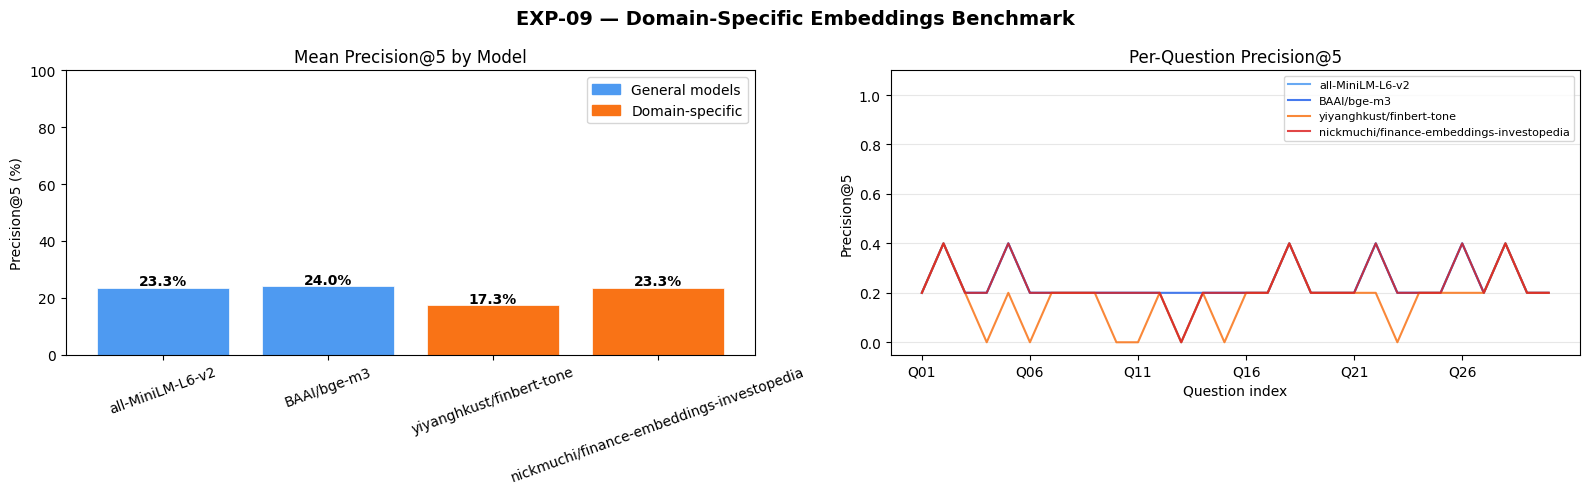

✅ Chart saved to exp09_outputs/exp09_charts.png


  EXP-09 CROSS-MODEL COMPARISON — PRECISION@5 SUMMARY
  Generated: 2026-04-22 13:33:35

  RANKING BY MEAN PRECISION@5

  #1  ████                  24.0%  BAAI/bge-m3 (General multilingual)
  #2  ████                  23.3%  all-MiniLM-L6-v2 (General baseline)
  #3  ████                  23.3%  nickmuchi/finance-embeddings-investopedia (Finance-specific)
  #4  ███                   17.3%  yiyanghkust/finbert-tone (FinBERT)

--------------------------------------------------------------------------------
  PER-QUESTION BREAKDOWN

  QID    A_MiniLM        B_BGE_M3        C_FinBERT       D_Finance_Inve
  ----------------------------------------------------------------------
  Q01      0.20            0.20            0.20            0.20          
  Q02      0.40            0.40            0.40            0.40          
  Q03      0.20            0.20            0.20            0.20          
  Q04      0.20            0.20            0.00  

In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 — Quick In-Notebook Visualisation
# View results directly in Colab without opening any files
# ─────────────────────────────────────────────────────────────────

# ── 1. Mean P@5 bar chart ─────────────────────────────────────────
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    labels  = [MODELS[mk]['label'].split('(')[0].strip() for mk in MODELS]
    scores  = [all_results[mk][1] * 100 for mk in MODELS]
    colors  = ['#4e9af1', '#4e9af1', '#f97316', '#f97316']  # blue=general, orange=domain

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('EXP-09 — Domain-Specific Embeddings Benchmark', fontsize=14, fontweight='bold')

    # Bar chart — overall
    bars = axes[0].bar(labels, scores, color=colors, edgecolor='white', linewidth=0.5)
    axes[0].set_title('Mean Precision@5 by Model', fontsize=12)
    axes[0].set_ylabel('Precision@5 (%)')
    axes[0].set_ylim(0, 100)
    axes[0].tick_params(axis='x', rotation=20)
    for bar, score in zip(bars, scores):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{score:.1f}%', ha='center', fontsize=10, fontweight='bold')
    blue_patch   = mpatches.Patch(color='#4e9af1', label='General models')
    orange_patch = mpatches.Patch(color='#f97316', label='Domain-specific')
    axes[0].legend(handles=[blue_patch, orange_patch])

    # Per-question heatmap-style line chart
    q_ids = [q['id'] for q in QUESTIONS]
    mk_colors = {'A_MiniLM': '#4e9af1', 'B_BGE_M3': '#2563eb',
                 'C_FinBERT': '#f97316', 'D_Finance_Investopedia': '#dc2626'}
    for mk in MODELS:
        p5_vals = [all_results[mk][0][i]['precision_at_5'] for i in range(len(QUESTIONS))]
        axes[1].plot(range(len(q_ids)), p5_vals,
                     label=MODELS[mk]['label'].split('(')[0].strip(),
                     color=mk_colors[mk], linewidth=1.5, alpha=0.85)

    axes[1].set_title('Per-Question Precision@5', fontsize=12)
    axes[1].set_xlabel('Question index')
    axes[1].set_ylabel('Precision@5')
    axes[1].set_xticks(range(0, 30, 5))
    axes[1].set_xticklabels([f'Q{i+1:02d}' for i in range(0, 30, 5)])
    axes[1].set_ylim(-0.05, 1.1)
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'exp09_charts.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Chart saved to exp09_outputs/exp09_charts.png')

except Exception as e:
    print(f'Chart rendering skipped: {e}')


# ── 2. Print the comparison summary inline ────────────────────────
print('\n')
with open(OUTPUT_DIR / 'comparison_summary.txt', 'r') as f:
    print(f.read())

In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 9 — Download All Output Files as a ZIP
# ─────────────────────────────────────────────────────────────────
import shutil
from google.colab import files

# Create a zip of all outputs
zip_path = '/content/exp09_all_outputs'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)

print('✅ ZIP created. Downloading now ...')
files.download(f'{zip_path}.zip')
print('\nIndividual files are also available in the Files panel → /content/exp09_outputs/')

✅ ZIP created. Downloading now ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Individual files are also available in the Files panel → /content/exp09_outputs/


## 📊 What to Do With the Outputs

You'll have these files in the downloaded ZIP:

```
exp09_outputs/
├── a_minilm_results.txt / .json
├── b_bge_m3_results.txt / .json
├── c_finbert_results.txt / .json
├── d_finance_investopedia_results.txt / .json
├── comparison_summary.txt / .json      ← start here
└── exp09_charts.png                    ← visual overview
```

**To do the analysis with Claude:**  
Upload `comparison_summary.txt` + any of the per-model `.txt` files to a new Claude conversation and ask:
- *"Which model performs best overall and why might that be?"*  
- *"Which specific financial topics benefit most from domain-specific embeddings?"*  
- *"Does difficulty level (basic/intermediate/advanced) interact with model type?"*  
- *"Given these results, when would you recommend using a domain-specific model vs a general one?"*